##### AI TECH - Akademia Innowacyjnych Zastosowań Technologii Cyfrowych. Programu Operacyjnego Polska Cyfrowa na lata 2014-2020
<hr>

## <br>
<br>
<br>
<br>
<br>
<br>
<br>
<center>
    <h1 style = "font-size:48px; font-weight:normal"><b>AI</b>-TECH</h1>
    <br>
<br>
<br>
<br>
    <h1 style = "font-size:24px; font-weight:normal">Przykład 2 DO LABORATORIUM 4</h1>
    <h1 style = "font-size:24px">z UCZENIA MASZYNOWEGO</h1>
    <h1 style = "font-size:24px">Metoda gradientu prostego, perceptron</h1>
    <h1 style = "font-size:24px">Tomasz Neumann</h1>
    <h3 style = "font-size:21px">Perceptron, SGDClassifier</h3>
</center>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
    </body>
    </html>

![stopka.svg](stopka.svg)

<center>
Projekt współfinansowany ze środków Unii Europejskiej w ramach Europejskiego Funduszu Rozwoju Regionalnego 
Program Operacyjny Polska Cyfrowa na lata 2014-2020,
Oś Priorytetowa nr 3 "Cyfrowe kompetencje społeczeństwa" Działanie  nr 3.2 "Innowacyjne rozwiązania na rzecz aktywizacji cyfrowej" 
Tytuł projektu:  „Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI Tech)”
    </center>

<hr>

# 1. Przykład 2

Perceptron stanowi jedną z najprostszych architektur SSN, zaproponowaną w 1957 roku przez Franka
Rosenblatta. Jego podstawą jest nieco zmodyfikowany sztuczny neuron, zwany progową jednostką logiczną (ang. Threshold Logic Unit — TLU) lub liniową jednostką progową (ang. Linear Threshold Unit — LTU). Wartościami wejść/wyjść są liczby (a nie stany binarne), a każde połączenie ma przyporządkowaną wagę. Jednostka TLU wylicza ważoną sumę sygnałów
wejściowych, a następnie zostaje użyta funkcja skokowa (najczęściej można spotkać rozwiązanie z funkcją skokową Heaviside'a lub funkcję signum) wobec tej sumy, dająca ostateczny wynik.

Pojedyncza jednostka TLU może być używana w prostych zadaniach klasyfikacji. Oblicza liniową
kombinację danych wejściowych i jeżeli wynik przekracza określony próg, to klasyfikuje przykład
do klasy pozytywnej, jeśli zaś rezultat nie przekroczy progu — do klasy negatywnej.
Przykładową implementację pojedynczej sieci TLU zawiera moduł Scikit-Learn w klasie Perceptron, co pokazuje poniższy fragment kodu.

In [3]:
#import zbioru danych oraz klasy Perceptron 
from sklearn.datasets import load_digits
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
X, y = load_digits(return_X_y=True)
clf = Perceptron()
clf.fit(X, y)
print(clf.score(X, y))
#ma być to samo
clf_sgd2 = SGDClassifier(loss="perceptron", eta0=1, learning_rate="constant", penalty=None)
clf_sgd2.fit(X, y)
print(clf_sgd2.score(X, y))


0.9393433500278241
0.9632721202003339


Okazuje się, że klasa Perceptron jest równoważna stosowaniu klasy SGDClassifier z następującymi parametrami: loss="perceptron", learning_rate="constant", eta0=1 (współczynnik uczenia) oraz penalty=None (brak regularyzacji).
Na tym etapie należy zwrócić uwagę, że w przeciwieństwie do klasyfikatorów regresji logistycznej, perceptrony nie wyliczają prawdopodobieństwa przynależności do klasy: określają one prognozy na podstawie wyznaczonego
progu. Jest to jeden z powodów, dla których warto wybierać klasyfikatory regresji logistycznej przed
perceptronami. Marvin Minsky i Seymour Papert w swojej monografii (1969) wykazali wiele poważnych wad modelu  perceptronu, zwłaszcza związanych z niemożnością rozwiązywania pewnych trywialnych problemów, stąd wielu badaczy porzuciło badania nad sieciami neuronowymi na rzecz bardziej ogólnych zagadnień. 

W tej części będziemy kontynuować wytrenowanie klasyfikatora stochastycznego spadku wzdłuż gradientu (Stochastic Gradient Descent — SGD z klasy SGDClassifier). Algorytm ten cechuje się możliwością wydajnego przetwarzania bardzo dużych zestawów danych. Wynika to częściowo z faktu, że klasyfikator SGD przetwarza poszczególne przykłady
uczące niezależnie od siebie, po jednym naraz (z tego powodu nadaje się on również do uczenia przyrostowego).
W przykładzie 1 tego notatnika zostania pokazana klasyfikacja dwóch zbiorów rozdzielonych liniowo wraz z podanym marginesem błędu dla tej linii. 

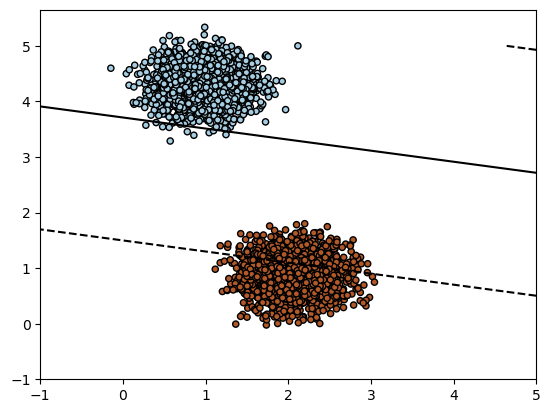

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# stworzenie danych wejściowych za pomocą klasy make_blobs
X, Y = make_blobs(n_samples=5000, centers=2, random_state=0, cluster_std=0.30)

# wybranie modelu i wytrenowanie klasyfikatora
#https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#sklearn.linear_model.SGDClassifier
clf = SGDClassifier(loss="perceptron", alpha=0.01, max_iter=200)
# clf = SGDClassifier(loss="hinge", alpha=0.01, max_iter=200)
# clf = SGDClassifier(loss="log_loss", alpha=0.01, max_iter=200)
clf.fit(X, Y)

# wykreślenie zbiorów punktów, lini rozdzielającej oraz jej odchyleń
xx = np.linspace(-1, 5, 10)
yy = np.linspace(-1, 5, 10)

X1, X2 = np.meshgrid(xx, yy)
Z = np.empty(X1.shape)
for (i, j), val in np.ndenumerate(X1):
    x1 = val
    x2 = X2[i, j]
    p = clf.decision_function([[x1, x2]])
    Z[i, j] = p[0]
levels = [-1.0, 0.0, 1.0]
linestyles = ['dashed', 'solid', 'dashed']
colors = 'k'
plt.contour(X1, X2, Z, levels, colors=colors, linestyles=linestyles)
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired,
            edgecolor='black', s=20)

plt.axis('tight')
plt.show()

W przykładzie 2 dane wejściowe będzie stanowił zbiór MNIST, który był już używany na poprzednich zajęciach. Jak pamiętamy, w tym zbiorze danych występuje 70 000 obrazów, a każdy z nich jest opisany 784 cechami. Wynika to
z faktu, że obraz ma rozmiar $28\times28$ pikseli i każda cecha opisuje natężenie szarości danego piksela
i przyjmuje wartości od 0 (kolor biały) do 255 (kolor czarny). Jak poprzednio użyjemy możliwości biblioteki tensorflow, która pobierze zbiór danych i podzieli go na część treningową i testową. Na tym etapie etykieta jest łańcuchem znaków, stąd też następuje przekształcenie etykiet na wartość całkowitoliczbową, gdyż większość algorytmów uczenia maszynowego spodziewa się wartości numerycznych.

In [5]:
import keras
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data(path='mnist.npz')
y_train = y_train.astype(np.uint8)
y_test = y_test.astype(np.uint8)
print("Training set size: ", X_train.shape)
print("Test set size: ", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training set size:  (60000, 28, 28)
Test set size:  (10000, 28, 28)


Następnie wyświetlony zostanie przykładowy obrazek z tego zbioru oraz jego etykieta (jak widzimy jest typu liczbowego).

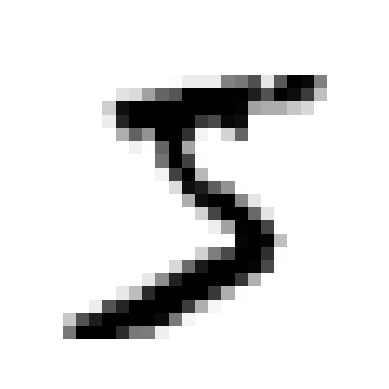

Prawdziwa etykieta:  5


In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
some_digit_image = X_train[0]
plt.imshow(some_digit_image, cmap = "binary")
plt.axis("off")
plt.show()
print('Prawdziwa etykieta: ', y_train[0])

Rozważony zostanie przykład klasyfikatora binarnego, który będzie rozpoznawał jedynie dwie klasy: piątki i pozostałe cyfry. Odpowiednie przekształcenie tego problemu zostało przedstawione w poniższym fragmencie kodu, który tworzy wartości True dla 5 i False dla pozostałych cyfr.

In [7]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)
print(y_train_5[0], y_train_5[1])

True False


Następnie wybrany zostaje klasyfikator SGD z klasy SGDClassifier i trenujemy go na zestawie danych wejściowych przeznaczonych do uczenia. Należy zwrócić uwagę na przygotowanie odpowiedniego kształtu danych do wybranego algorytmu. Skuteczność klasyfikatora SGDClassifier zależy od losowości na etapie uczenia, a jeżeli chcemy mieć powtarzalne wyniki należy wyznaczyć wartość parametru random_state.

In [8]:
from sklearn.linear_model import SGDClassifier
print(X_train.shape[0], X_train.shape[1],X_train.shape[2] )
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1]*X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1]*X_test.shape[2])
print(X_train.shape)
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

60000 28 28
(60000, 784)


,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


Na tym etapie możemy sprawdzić , jak klasyfikator zgaduje, że na obrazie jest cyfra 5. W przypadku pierwszego obrazu nie pomylił się (wyświetliliśmy powyżej piątkę), jak i wartość dokładności klasyfikatora na poziomie 95% wygląda bardzo dobrze.

In [9]:
print(sgd_clf.predict(X_train))
print(sgd_clf.predict(X_test))

print(sgd_clf.score(X_train, y_train_5))
print(sgd_clf.score(X_test, y_test_5))

[ True False False ...  True False False]
[False False False ... False  True False]
0.9522666666666667
0.9492


Jednak dobrym sposobem oceny modelu jest użycie sprawdzianu krzyżowego. Wykonamy w tym celu kroswalidację 5-krotną (parametr cv=5) za pomocą funkcji <i>cross_val_score()</i>.

In [10]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=5, scoring="accuracy")

array([0.95466667, 0.96975   , 0.9635    , 0.96533333, 0.94841667])

Tutaj także uzyskuje się wynik prawidłowych prognoz w okolicach 95%.

Prześledźmy więc działanie prostego klasyfikatora, który kalsyfikuje jedynie obrazy nie będące piątkami

In [11]:
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

oraz wyznaczmy jego dokładność.

In [12]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=5, scoring="accuracy")

array([0.91266667, 0.90866667, 0.9095    , 0.90883333, 0.90858333])

Tu uzyskujemy dokładność w okolicach 90%. Jak widać nierówne zbiory danych dla poszczególnych etykiet mogą mieć ogromne znaczenie. Z powyższego eksperymentu wynika, że gdybyśmy zgadywali, ze dany obraz nie jest piątką mielibyśmy rację  w 90% przypadkach - około 10% stanowią tylko piątki, stąd dokładność nie stanowi dobrej miary wydajności klasyfikatorów w takiego typu zbiorach danych.

Lepszym sposobem oceny wydajności klasyfikatora jest analiza macierzy pomyłek. W celu obliczenia macierzy pomyłek musimy najpierw uzyskać zbiór prognoz, które porównamy z rzeczywistymi wartościami docelowymi. W tym celu posłużymy się funkcją <i>cross_val_predict()</i>, która przeprowadzi <i>k</i>-krotny test krzyżowy zwracając prognozy dla każdego podzbioru. 

In [13]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=5)

Następnie można uzyskać macierz pomyłek podając etykiety wejściowe oraz te przewidziane przez klasyfikator.

In [14]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5, y_train_pred)

array([[53115,  1464],
       [  916,  4505]])

Macierz pomyłek dostarcza wielu informacji, czasami jednak przydaje się bardziej zwięzły wskaźnik. Interesującym rozwiązaniem okazuje się dokładność pozytywnych prognoz (precyzja klasyfikatora) oraz czułość - odsetek prawdziwych pozytywnych prognoz.

Moduł <i>scikit-learn</i> zawiera kilka funkcji obliczających wskaźniki klasyfikatorów, w tym również precyzję (<i>precision_score()</i>) i czułość (<i>recall_score()</i>).

In [15]:
from sklearn.metrics import precision_score, recall_score
print(precision_score(y_train_5, y_train_pred)) 

print(recall_score(y_train_5, y_train_pred))

0.7547327860613168
0.8310274857037447


Przy tych wskaźnikach klasyfikator już nie wygląda tak dobrze. Okazuje się, że jak rozpoznaje cyfrę 5, nie myli się w 75% przypadków, a prawidłowo rozpoznaje 83% piątek.

W celu porównania dwoch klasyfikatorów często łączy się precyzję oraz czułość w jednym wskaźniku zwanym F1-score. Wynik F1-score stanowi średnią harmoniczną precyzji i pełności. Standardowa średnia traktuje wszystkie wartości jednakowo,
natomiast średnia harmoniczna nadaje większą wagę małym wartościom. W rezultacie klasyfikator uzyska dużą wartość wyniku F1 jedynie wtedy, gdy zarówno precyzja, jak i pełność będą miały dużą wartość. F1-score w module scikit-learn realizuje funkcja <i>f1_score()</i>.

In [16]:
from sklearn.metrics import f1_score
print(f1_score(y_train_5, y_train_pred))

0.7910447761194029


Wynik F1-score faworyzuje klasyfikatory mające zbliżone wartości precyzji i pełności. Nie zawsze tego chcemy:
w pewnych sytuacjach zależy nam bardziej na precyzji, a w innych na pełności.

Przyjrzyjmy się więc, w jaki sposób klasyfikator SGDClassifier podejmuje decyzje. Dla każdej próbki zostaje wyliczony wynik na podstawie funkcji decyzyjnej. Jeżeli jego wartość przekroczy określony próg, przykład ten zostanie przydzielony do klasy pozytywnej - w przeciwnym wypadku będzie wyznaczony do klasy negatywnej.

Moduł Scikit-Learn nie pozwala na bezpośrednie dobieranie progów, ale daje nam dostęp do wyników decyzyjnych, za pomocą których są wyliczane prognozy. Zamiast wywoływać metodę <i>predict()</i>, możemy skorzystać z metody <i>decision_function()</i>, która zwraca obliczony wynik dla każdej próbki, a następnie wyliczyć prognozy na podstawie tych wyników przy użyciu dowolnego progu.

In [17]:
y_scores = sgd_clf.decision_function(X_train)
print(y_scores)
print('Wynik funkcji predict(): ', sgd_clf.predict(X_train))

threshold = 0
y_some_digit_pred = (y_scores > threshold)
print('Wynik funkcji decision_function(): ', y_some_digit_pred)

[  2164.22030239  -5897.37359354 -13489.14805779 ...   6007.43513003
   -695.89564908  -3991.49590678]
Wynik funkcji predict():  [ True False False ...  True False False]
Wynik funkcji decision_function():  [ True False False ...  True False False]


Klasyfikator SGDClassifier korzysta z progu o wartości 0, dlatego powyżej wyświetliły się takie same rezultaty obydwu funkcji. Można jednak zmienić próg (zwiększyć w tym przypadku do 5000)

In [18]:
threshold = 5000
y_some_digit_pred = (y_scores > threshold)
print('Wynik funkcji po ustaleniu nowej wartości progowej: ', y_some_digit_pred)

Wynik funkcji po ustaleniu nowej wartości progowej:  [False False False ...  True False False]


co spowoduje, że pierwsza próbka nie będzie rozpoznawana jako 5-ka przy tym progu. Tak więc podniesienie progu zmniejsza czułość klasyfikatora.

Aby dobrać najlepszy próg w module <i>scikit-learn</i> można skorzystać z funkcji <i>cross_val_predict()</i>, aby w tym przypadku uzyskać wyniki decyzyjne a nie prognozy.

In [21]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=5, method="decision_function")

Korzystając z tych wyników można wyliczyć precyzję, czułość i próg za pomocą funkcji <i>precision_recall_curve()</i>.

In [22]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

Ostatecznie można wygenerować wykres precyzji i czułości w zależności od progu decyzyjnego.

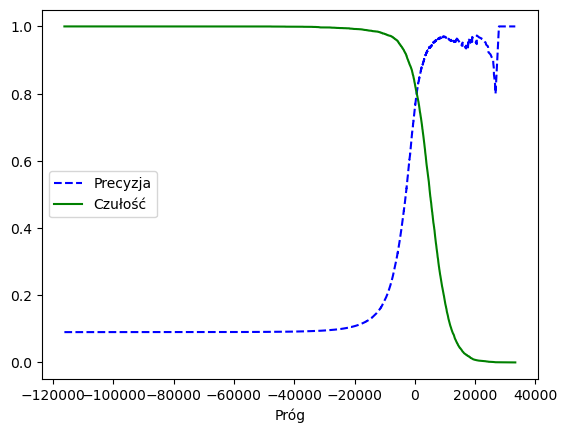

In [23]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precyzja")
    plt.plot(thresholds, recalls[:-1], "g-", label="Czułość")
    plt.xlabel("Próg")
    plt.legend()

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

Innym sposobem wyznaczenia dobrego kompromisu jest narysowanie wykresu precyzji bezpośrednio w funkcji czułości.

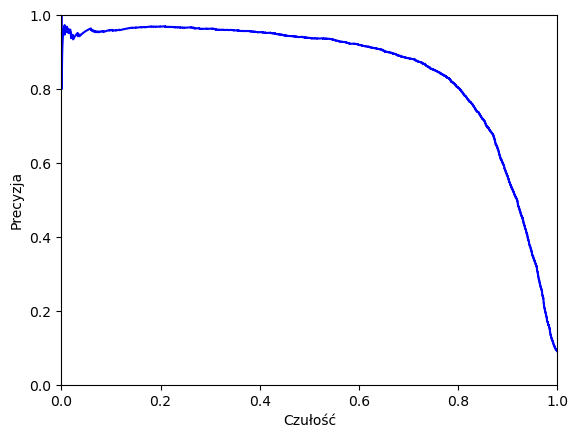

In [24]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls[:-1], precisions[:-1], "b")
    plt.xlabel("Czułość")
    plt.ylabel("Precyzja")
    plt.xlim(0,1)
    plt.ylim(0,1)
    
plot_precision_vs_recall(precisions, recalls)
plt.show()

Dla zwiększenia dokładności można poszukać najmniejszego progu zapewniającego precyzję rzędu co najmniej 90% (funkcja <i>np.argmax()</i> wyznaczy pierwszy indeks wartości maksymalnej, co w tym przypadku oznacza pierwszą wartość true).

In [25]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
print(threshold_90_precision)

y_train_pred_90 = (y_scores > threshold_90_precision)
print('Precyzja po ustaleniu nowego progu', precision_score(y_train_5, y_train_pred_90))
print('Czułość dla wybranej wartości precyzji', recall_score(y_train_5, y_train_pred_90))

3045.925822705365
Precyzja po ustaleniu nowego progu 0.9001764557600201
Czułość dla wybranej wartości precyzji 0.6587345508208817


Powyższe operacje pokazują, jak uzyskać klasyfikator z 90% precyzją, jednak może on być mało przydatny jeśli ma małą pełność.

W celu dalszej analizy tego typu problemu w przypadku kalasyfikatorów binarnych można skorzystać z interpretacji krzywej ROC (<i>receiver operating characteristic</i>). W jej przypadku wykreślany jest odsetek prawdziwie pozytywnych w funkcji odsetka fałszywie pozytywnych - jest to odsetek negatywnych przykładów, które zostały nieprawidłowo sklasyfikowane jako pozytywne. Otrzymuje się tę wartość, odejmując odsetek prawdziwie negatywnych od liczby 1. Jak można się domyślać, jest to odsetek negatywnych próbek, które zostały prawidłowo sklasyfikowane jako negatywne. Wartość ta bywa również nazywana specyficznością. 
W celu wykreślenia krzywej ROC można skorzystać z funkcji <i>roc_curve()</i>.

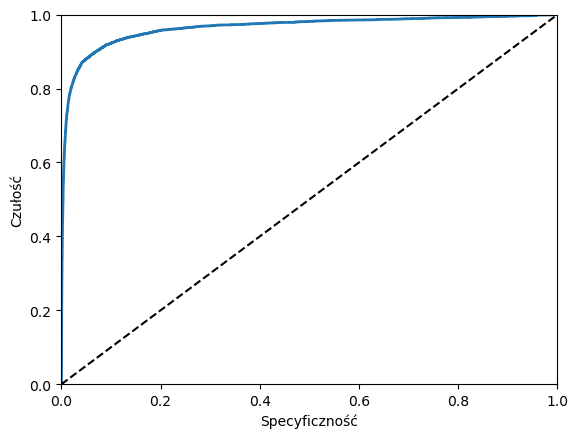

In [26]:
from sklearn.metrics import roc_curve
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # Przerywana przekątna wykresu
    plt.ylabel("Czułość")
    plt.xlabel("Specyficzność")
    plt.xlim(0,1)
    plt.ylim(0,1)

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
plot_roc_curve(fpr, tpr)
plt.show()

W tym przypadku nalezy także pójść na kompromis: im wyższa wartość pełności tym więcej fałszywie pozytywnych przypadków wskazuje klasyfikator. Linia przerywana symbolizuje krzywą ROC całkowicie losowego klasyfikatora -  dobry klasyfikator stara się nie zbliżać do tej prostej (czyli dąży do lewej górnej części wykresu).

Jednym ze sposobów porównania klasyfikatorów jest pomiar ich obszaru pod krzywą (<i>area
under the curve</i> - AUC), co w przypadku scikit-learn realizuje funkcja <i>roc_auc_score()</i>.

In [27]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_train_5, y_scores))

0.9648211175804801


Obszar AUC w przypadku doskonałego klasyfikatora byłby równy 1.0, natomiast w całkowicie losowym klasyfikatorze ma on wartość 0.5.

# Zadania do wykonania

<p><b>Zadanie 1</b></p>
Dla przykładu 1 przeprowadź eksperymenty pokazujące wpływ wyboru funkcji straty oraz współczynników uczenia (zgodnie z dokumentacją) na końcowy wynik klasyfikacji.

In [41]:
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_blob, y_blob = make_blobs(n_samples=5000, centers=2, random_state=0, cluster_std=0.30)
X_train_blob, X_test_blob, y_train_blob, y_test_blob = train_test_split(
    X_blob, y_blob, test_size=0.2, random_state=42, stratify=y_blob
)

rows = []
for loss in ["perceptron", "hinge", "log_loss"]:
    for eta0 in [0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 20.0, 30.0, 50.0, 100.0]:
        model = SGDClassifier(
            loss=loss,
            alpha=0.01,
            max_iter=20,
            learning_rate="constant",
            eta0=eta0,
            random_state=42,
        )
        model.fit(X_train_blob, y_train_blob)
        rows.append({
            "loss": loss,
            "eta0": eta0,
            "accuracy": accuracy_score(y_test_blob, model.predict(X_test_blob)),
        })

task1_results = pd.DataFrame(rows).pivot(index="loss", columns="eta0", values="accuracy")
print(task1_results.to_string(float_format=lambda x: f"{x:.3f}"))


eta0        0.001    0.010    0.100    1.000    5.000    10.000   20.000   30.000   50.000   100.000
loss                                                                                                
hinge         1.000    1.000    1.000    1.000    1.000    0.916    1.000    1.000    1.000    0.500
log_loss      1.000    1.000    1.000    1.000    1.000    1.000    1.000    0.669    1.000    0.500
perceptron    1.000    1.000    1.000    1.000    1.000    0.916    0.766    1.000    0.500    0.500


<p><b>Wnioski do zadania 1</b></p>

Dla danych z przykładu 1 wszystkie sprawdzone kombinacje funkcji straty (`perceptron`, `hinge`, `log_loss`) i współczynnika uczenia (`eta0` od `0.001` do `5.0`) uzyskały `accuracy=1` na zbiorze testowym.

Ustawienie `eta0` zmieniło wynik klasyfikacji dopiero dla wartości 10.0 i wyżej.

Przy takich wyższych wartościach w zależności od funkcji straty wyniki prezentują się różnie, ale nie widać jakiegoś konkretnego wzorca. Czasmi wynik 100% uzyskuje jedna funkcja straty, czasami inna. Dla eta = 100 wszystkie funkcje straty uzyskują bardzo słaby wynik 0.5

Wniosek z tych konkretnych wyników jest taki, że wygenerowane zbiory są bardzo łatwo separowalne liniowo. Przy tak prostych danych badane ustawienia dają ten sam końcowy efekt, więc nie widać przewagi jednej funkcji straty nad inną.

Co nie oznacza, że funkcja straty nigdy nie ma znaczenia. Oznacza tylko, że akurat ten syntetyczny zbiór z make_blobs był na tyle łatwo separowalny, że różne ustawienia SGDClassifier poradziły sobie identycznie na zbiorze testowym.

<p><b>Zadanie 2</b></p>
Dla przykładu 2 przeprowadź sprawdzenie walidacji krzyżowej dla kilku wartości $k$ - w jaki sposób wpływa to na wartości dokładności, precyzji, czułości i F-score? Eksperymenty przeprowadź w ten sposób, że klasę pozytywną będzie reprezentowała wyłącznie ostatnia cyfra Twojego numeru albumu.

Klasą pozytywną jest ostatnia cyfra indeksu `193257`, czyli `7`.


In [ ]:
import pandas as pd
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_predict

positive_digit = 193257 % 10
X_train_cv = X_train.reshape(len(X_train), -1)
y_train_positive = y_train == positive_digit

rows = []
for cv in [3, 5, 10]:
    y_pred = cross_val_predict(SGDClassifier(random_state=42), X_train_cv, y_train_positive, cv=cv)
    rows.append({
        "cv": cv,
        "accuracy": accuracy_score(y_train_positive, y_pred),
        "precision": precision_score(y_train_positive, y_pred),
        "recall": recall_score(y_train_positive, y_pred),
        "f1": f1_score(y_train_positive, y_pred),
    })

task2_results = pd.DataFrame(rows)
print(task2_results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))


 cv  accuracy  precision   recall       f1
  3  0.969300   0.828554 0.890184 0.858264
  5  0.977950   0.908295 0.877414 0.892587
 10  0.975533   0.881259 0.884916 0.883084


<p><b>Wnioski do zadania 2</b></p>

Dla klasy pozytywnej `7` najlepszy wynik F1 uzyskała walidacja `cv=5` (`F1=0.892`). Ten wariant miał też najwyższą dokładność (`accuracy=0.977`) i precyzję (`precision=0.908`).

Dla `cv=3` czułość była najwyższa (`recall=0.890`), ale precyzja była niższa (`0.828`), co obniżyło F1 do `0.858`. Dla `cv=10` wynik był pośredni (`F1=0.883`). Na podstawie tych wyników `cv=5` daje najlepszy kompromis między precyzją i czułością.

Dokładność klasyfikacji bywa myląca, szczególnie przy nierównych klasach. Dla cyfry 7 wysokie accuracy występuje we wszystkich wariantach walidacji, ale precision, recall i F1 pokazują różnice między cv=3, cv=5 oraz cv=10. Najbardziej sensowna ocena wymaga patrzenia na kilka metryk, zwłaszcza gdy klasa pozytywna jest rzadsza od negatywnej.